# Kennicott Glacier: what mass-balance profile gives zero net mass balance?

This notebook works toward the question: **given the actual shape of Kennicott
Glacier (its area-elevation distribution, i.e. hypsometry), what surface
mass-balance-vs-elevation profiles `b(z)` produce zero net (glacier-wide)
mass balance?**

Steps:

1. Load the local `kennicott_COP30_DEM_epsg32607.tif` Copernicus GLO-30 DEM
   (already reprojected into UTM Zone 7N).
2. Download the RGI (Randolph Glacier Inventory) Region 01 - Alaska outlines.
3. Select the Kennicott (RGI60-01.15645) and Root (RGI60-01.26722) Glacier
   outlines, merge them into a single outline, and use it to subset/clip the
   DEM (Root is a tributary that joins Kennicott's main trunk).
4. Build the combined glacier's hypsometry (area per elevation band).
5. Define a parametric mass-balance profile `b(z)` (piecewise-linear, matched
   to the elevation-dependent surface mass balance parameterization used in
   PISM for this glacier) and solve for the parameter combinations
   (equilibrium-line altitude, balance gradients) that zero out the
   area-weighted net balance.


## 1. Imports and configuration

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.plot import plotting_extent
from shapely.geometry import mapping
import requests
from scipy.optimize import brentq

# Project directory (this notebook's folder)
PROJ_DIR = Path.cwd()
DEM_PATH = PROJ_DIR / "kennicott_COP30_DEM_epsg32607.tif"

# Local cache for downloaded RGI data (kept out of git via .gitignore below)
DATA_DIR = PROJ_DIR / "rgi_data"
DATA_DIR.mkdir(exist_ok=True)

# RGI v6.0 region 01 (Alaska), mirrored (no-auth) by OGGM from the official
# GLIMS/RGI distribution.
RGI01_URL = (
    "https://cluster.klima.uni-bremen.de/~oggm/rgi/www.glims.org/RGI/"
    "rgi60_files/01_rgi60_Alaska.zip"
)
RGI01_ZIP = DATA_DIR / "01_rgi60_Alaska.zip"
RGI01_DIR = DATA_DIR / "01_rgi60_Alaska"

# RGI IDs for Kennicott and (tributary) Root Glacier (verified below by name match too)
KENNICOTT_RGI_ID = "RGI60-01.15645"
ROOT_RGI_ID = "RGI60-01.26722"

RHO_ICE = 910.0  # kg/m^3, ice density used to convert kg/m^2 -> m ice-equivalent


## 2. Load the DEM

`kennicott_COP30_DEM_epsg32607.tif` is a Copernicus GLO-30 DEM already
reprojected into UTM Zone 7N (EPSG:32607) at its native ~22 m ground
sampling, with `nodata = 0.0`. Working in this projected CRS gives equal-area,
metre-sized pixels for the hypsometry calculation later on (pixel areas in
geographic/degree coordinates would otherwise vary with latitude).

(An earlier version of this file, `kennicott_COP30_DEM.tif`, had a mismatched
CRS tag -- geographic coordinates labelled as UTM 7N -- and turned out to
contain no actual elevation data at all. This file supersedes it.)


In [2]:
with rasterio.open(DEM_PATH) as src:
    dem_crs = src.crs
    dem_bounds = src.bounds
    dem_transform = src.transform
    dem_nodata = src.nodata
    dem_raw = src.read(1)

print("DEM CRS:             ", dem_crs)
print("DEM bounds (m):      ", dem_bounds)
print("Pixel size (m):      ", dem_transform.a, -dem_transform.e)
print("Shape (rows, cols):  ", dem_raw.shape)
print("Nodata value:        ", dem_nodata)

assert dem_crs.is_projected, f"Expected a projected (metric) CRS, got {dem_crs}"
DST_CRS = dem_crs  # used below to reproject the RGI polygon to match

# Basic data-quality guard: catch an empty/placeholder DEM early with a clear
# message, rather than a cryptic failure several cells downstream.
finite = dem_raw[dem_raw != dem_nodata]
elev_range = finite.max() - finite.min() if finite.size else 0
print("Elevation range (m):  ", finite.min() if finite.size else float("nan"),
      "to", finite.max() if finite.size else float("nan"))

assert finite.size and elev_range > 100, (
    f"DEM looks empty or degenerate (elevation range = {elev_range:.1f} m over "
    f"{finite.size} valid pixels). Kennicott spans ~400-4400 m, so this file "
    "does not contain real elevation data -- re-export/replace it before continuing."
)


DEM CRS:              EPSG:32607
DEM bounds (m):       BoundingBox(left=355835.0834039927, bottom=6774703.643437139, right=421910.7914293837, top=6876834.714389734)
Pixel size (m):       22.106292413981596 22.106292413981596
Shape (rows, cols):   (4620, 2989)
Nodata value:         0.0
Elevation range (m):   219.55537 to 4987.373


## 3. Download RGI Region 01 (Alaska), select Kennicott + Root Glacier, and merge outlines

In [3]:
if not RGI01_DIR.exists():
    if not RGI01_ZIP.exists():
        print(f"Downloading RGI v6.0 Region 01 (Alaska) from:\n  {RGI01_URL}")
        resp = requests.get(RGI01_URL, timeout=120)
        resp.raise_for_status()
        RGI01_ZIP.write_bytes(resp.content)
        print(f"Downloaded {RGI01_ZIP.stat().st_size / 1e6:.1f} MB.")
    else:
        print("Zip already cached locally, skipping download.")

    RGI01_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(RGI01_ZIP) as zf:
        zf.extractall(RGI01_DIR)
    print(f"Extracted to {RGI01_DIR}")
else:
    print("RGI Region 01 already downloaded and extracted, skipping.")


RGI Region 01 already downloaded and extracted, skipping.


In [4]:
rgi01_shp = next(RGI01_DIR.glob("*.shp"))
rgi01 = gpd.read_file(rgi01_shp)
print(f"Loaded {len(rgi01)} glacier outlines for RGI Region 01 (Alaska), CRS={rgi01.crs}")

# Select Kennicott and Root Glaciers -- match by RGIId, with names as a sanity check
selected = rgi01[rgi01["RGIId"].isin([KENNICOTT_RGI_ID, ROOT_RGI_ID])].copy()
assert len(selected) == 2, f"Expected 2 matches for {KENNICOTT_RGI_ID}/{ROOT_RGI_ID}, got {len(selected)}"
print(selected[["RGIId", "Name", "Area", "CenLon", "CenLat", "Zmin", "Zmax", "Zmed"]])

names_lower = selected["Name"].str.lower()
assert names_lower.str.contains("kennicott").any(), "Kennicott not found -- check RGIId."
assert names_lower.str.contains("root").any(), "Root not found -- check RGIId."

# Merge (dissolve) the two outlines into a single polygon -- Root is a
# tributary that joins Kennicott's main trunk, so the combined outline gives
# one continuous ice mask to clip the DEM against.
kennicott_root = gpd.GeoDataFrame(
    {"Name": ["Kennicott + Root"]}, geometry=[selected.union_all()], crs=selected.crs
)
combined_rgi_area_km2 = selected["Area"].sum()
print(f"\nCombined (Kennicott + Root) RGI area: {combined_rgi_area_km2:.2f} km^2")


Loaded 27108 glacier outlines for RGI Region 01 (Alaska), CRS=EPSG:4326
                RGIId               Name     Area      CenLon     CenLat  \
15640  RGI60-01.15645  Kennicott Glacier  292.531 -143.043365  61.572723   
26717  RGI60-01.26722       Root Glacier   82.477 -142.899000  61.633000   

       Zmin  Zmax  Zmed  
15640   399  4432  1826  
26717   570  3952  2190  

Combined (Kennicott + Root) RGI area: 375.01 km^2


## 4. Subset the DEM by the merged Kennicott + Root Glacier outline

In [5]:
# Reproject the merged glacier polygon into the DEM's CRS (UTM 7N)
outline_utm = kennicott_root.to_crs(DST_CRS)
geom_utm = [mapping(outline_utm.iloc[0].geometry)]

with rasterio.open(DEM_PATH) as src:
    clipped_arr, clipped_transform = rio_mask(
        src, geom_utm, crop=True, filled=True, nodata=np.nan
    )
    clipped_profile = src.profile.copy()

clipped_arr = clipped_arr[0].astype("float64")
# Also treat the source's own nodata sentinel (0.0) as invalid, not just the
# area outside the polygon (rio_mask only fills the exterior).
clipped_arr[clipped_arr == dem_nodata] = np.nan
clipped_profile.update(
    height=clipped_arr.shape[0],
    width=clipped_arr.shape[1],
    transform=clipped_transform,
    dtype="float64",
    nodata=np.nan,
)

valid = np.isfinite(clipped_arr)
print(f"Clipped raster shape:   {clipped_arr.shape}")
print(f"Valid (on-glacier) px:  {valid.sum()} of {clipped_arr.size}")
print(f"Elevation range (m):    {clipped_arr[valid].min():.0f} to {clipped_arr[valid].max():.0f}")

pixel_area_m2 = abs(clipped_transform.a * clipped_transform.e)
glacier_area_km2 = valid.sum() * pixel_area_m2 / 1e6
print(f"Pixel area:             {pixel_area_m2:.1f} m^2")
print(f"DEM-derived area:       {glacier_area_km2:.2f} km^2  (combined RGI inventory area: {combined_rgi_area_km2:.2f} km^2)")


Clipped raster shape:   (1587, 1350)
Valid (on-glacier) px:  766970 of 2142450
Elevation range (m):    408 to 4960
Pixel area:             488.7 m^2
DEM-derived area:       374.81 km^2  (combined RGI inventory area: 375.01 km^2)


In [6]:
# Write the clipped DEM to disk alongside the source DEM
clip_path = PROJ_DIR / "kennicott_glacier_DEM_clip_UTM7N.tif"
with rasterio.open(clip_path, "w", **clipped_profile) as dst:
    dst.write(clipped_arr, 1)
print(f"Wrote clipped DEM to {clip_path.name}")


Wrote clipped DEM to kennicott_glacier_DEM_clip_UTM7N.tif


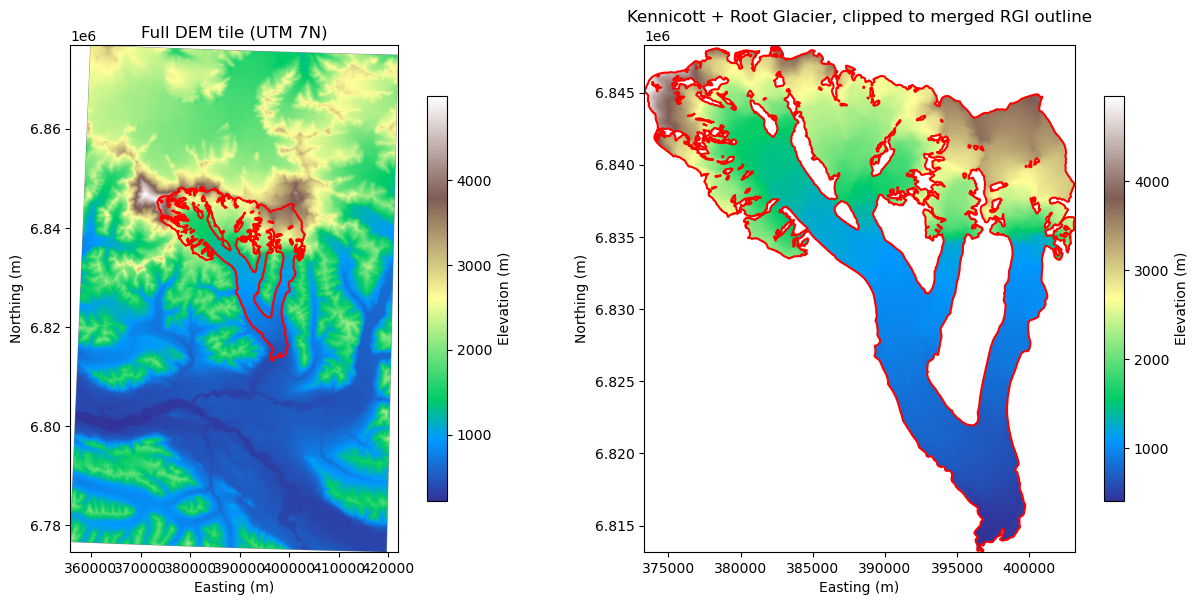

In [7]:
def plot_dem_overview(dem_path, dem_nodata, outline_utm, clipped_arr, clipped_transform):
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    with rasterio.open(dem_path) as dem_ds:
        dem_full = np.ma.masked_equal(dem_ds.read(1), dem_nodata)
        extent_full = plotting_extent(dem_ds)
    im0 = axes[0].imshow(dem_full, cmap="terrain", extent=extent_full)
    axes[0].set_title("Full DEM tile (UTM 7N)")
    fig.colorbar(im0, ax=axes[0], label="Elevation (m)", shrink=0.8)
    outline_utm.boundary.plot(ax=axes[0], color="red", linewidth=1.5)

    im1 = axes[1].imshow(
        clipped_arr,
        cmap="terrain",
        extent=(
            clipped_transform.c,
            clipped_transform.c + clipped_arr.shape[1] * clipped_transform.a,
            clipped_transform.f + clipped_arr.shape[0] * clipped_transform.e,
            clipped_transform.f,
        ),
    )
    outline_utm.boundary.plot(ax=axes[1], color="red", linewidth=1.5)
    axes[1].set_title("Kennicott + Root Glacier, clipped to merged RGI outline")
    fig.colorbar(im1, ax=axes[1], label="Elevation (m)", shrink=0.8)
    for ax in axes:
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()


plot_dem_overview(DEM_PATH, dem_nodata, outline_utm, clipped_arr, clipped_transform)


## 5. Hypsometry: area per elevation band

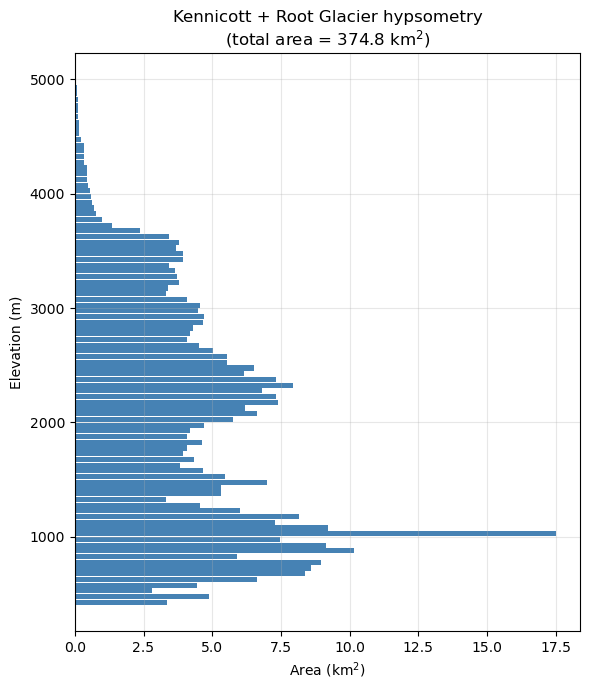

In [8]:
elevations = clipped_arr[valid]

BIN_WIDTH = 50.0  # metres
bin_start = np.floor(elevations.min() / BIN_WIDTH) * BIN_WIDTH
bin_stop = np.ceil(elevations.max() / BIN_WIDTH) * BIN_WIDTH
bin_stop = max(bin_stop, bin_start + BIN_WIDTH)  # guard against a degenerate (near-zero) elevation range
bin_edges = np.arange(bin_start, bin_stop + BIN_WIDTH, BIN_WIDTH)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

counts, _ = np.histogram(elevations, bins=bin_edges)
area_km2_per_bin = counts * pixel_area_m2 / 1e6
total_area_km2 = area_km2_per_bin.sum()


def plot_hypsometry(bin_centers, area_km2_per_bin, bin_width, total_area_km2):
    """Area (km^2) as a function of elevation (m) -- the glacier's hypsometry."""
    fig, ax = plt.subplots(figsize=(6, 7))
    ax.barh(bin_centers, area_km2_per_bin, height=bin_width * 0.9, color="steelblue")
    ax.set_xlabel("Area (km$^2$)")
    ax.set_ylabel("Elevation (m)")
    ax.set_title(f"Kennicott + Root Glacier hypsometry\n(total area = {total_area_km2:.1f} km$^2$)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_hypsometry(bin_centers, area_km2_per_bin, BIN_WIDTH, total_area_km2)


## 6. Mass balance profile: reference parameterization

The cell below records the elevation-dependent surface mass balance (SMB)
configuration Bruno is using to drive PISM for Kennicott Glacier (see the
[PISM manual, `surface.elevation_dependent`
section](https://www.pism.io/docs/manual/parameters/index.html#surface.elevation_dependent.T_min)).
It defines a piecewise-linear `M(z)` profile: flat at `M_limit_min` below
`z_M_min`, ramping linearly through 0 at `z_ELA`, up to `M_max` at `z_M_max`,
then flat at `M_limit_max` above.


In [9]:
"""
Config file that Bruno is using to drive the surface mass balance of
Kennicott Glacier. This is per the instructions in
https://www.pism.io/docs/manual/parameters/index.html#surface.elevation_dependent.T_min

[surface.options.elevation_dependent]

'surface.models' = "elevation_dependent"

'surface.elevation_dependent.z_M_min' = 700
'surface.elevation_dependent.M_min' = -8.80         # = -8000 kg/m^2 / 910 kg/m^3
'surface.elevation_dependent.z_ELA' = 1750
'surface.elevation_dependent.z_M_max' = 2200
'surface.elevation_dependent.M_max' = 2.42
'surface.elevation_dependent.M_limit_min' = -8.80
'surface.elevation_dependent.M_limit_max' = 2.42
"""


'\nConfig file that Bruno is using to drive the surface mass balance of\nKennicott Glacier. This is per the instructions in\nhttps://www.pism.io/docs/manual/parameters/index.html#surface.elevation_dependent.T_min\n\n[surface.options.elevation_dependent]\n\n\'surface.models\' = "elevation_dependent"\n\n\'surface.elevation_dependent.z_M_min\' = 700\n\'surface.elevation_dependent.M_min\' = -8.80         # = -8000 kg/m^2 / 910 kg/m^3\n\'surface.elevation_dependent.z_ELA\' = 1750\n\'surface.elevation_dependent.z_M_max\' = 2200\n\'surface.elevation_dependent.M_max\' = 2.42\n\'surface.elevation_dependent.M_limit_min\' = -8.80\n\'surface.elevation_dependent.M_limit_max\' = 2.42\n'

Net specific balance with Bruno's PISM config (ELA = 1750 m): -1.559 m ice-eq/yr


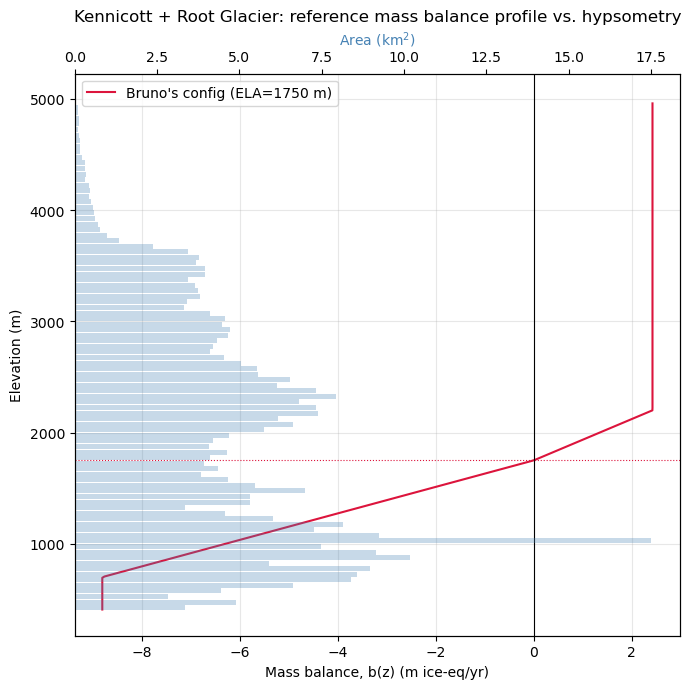

In [10]:
# PISM elevation_dependent parameters (units: m ice-equivalent per year)
PISM_PARAMS = dict(
    z_M_min=700.0,
    M_min=-8.80,
    z_ELA=1750.0,
    z_M_max=2200.0,
    M_max=2.42,
    M_limit_min=-8.80,
    M_limit_max=2.42,
)

def mass_balance_profile(z, z_M_min, M_min, z_ELA, z_M_max, M_max,
                          M_limit_min, M_limit_max):
    """PISM's elevation_dependent surface mass balance, b(z).

    Piecewise-linear through (z_M_min, M_min) -> (z_ELA, 0) -> (z_M_max, M_max),
    clamped to M_limit_min / M_limit_max outside [z_M_min, z_M_max].
    """
    z = np.asarray(z, dtype=float)
    b = np.empty_like(z)

    below = z <= z_M_min
    ablation = (z > z_M_min) & (z <= z_ELA)
    accumulation = (z > z_ELA) & (z <= z_M_max)
    above = z > z_M_max

    b[below] = M_limit_min
    b[ablation] = M_min * (z_ELA - z[ablation]) / (z_ELA - z_M_min)
    b[accumulation] = M_max * (z[accumulation] - z_ELA) / (z_M_max - z_ELA)
    b[above] = M_limit_max
    return b


def net_specific_balance(bin_centers, area_km2_per_bin, **profile_kwargs):
    """Area-weighted net balance (m ice-eq/yr) over the hypsometry."""
    b = mass_balance_profile(bin_centers, **profile_kwargs)
    total_area = area_km2_per_bin.sum()
    return float(np.sum(b * area_km2_per_bin) / total_area)


B_net_pism = net_specific_balance(bin_centers, area_km2_per_bin, **PISM_PARAMS)
print(f"Net specific balance with Bruno's PISM config (ELA = {PISM_PARAMS['z_ELA']:.0f} m): "
      f"{B_net_pism:+.3f} m ice-eq/yr")


def plot_mass_balance_reference(elevations, pism_params, bin_centers, area_km2_per_bin, bin_width):
    """Reference mass balance profile b(z), with the hypsometry as a second (twinned) axis."""
    fig, ax1 = plt.subplots(figsize=(7, 7))

    z_plot = np.linspace(elevations.min(), elevations.max(), 400)
    ax1.plot(mass_balance_profile(z_plot, **pism_params), z_plot,
             color="crimson", label=f"Bruno's config (ELA={pism_params['z_ELA']:.0f} m)")
    ax1.axvline(0, color="k", lw=0.8)
    ax1.axhline(pism_params["z_ELA"], color="crimson", lw=0.8, ls=":")
    ax1.set_xlabel("Mass balance, b(z) (m ice-eq/yr)")
    ax1.set_ylabel("Elevation (m)")
    ax1.legend(loc="upper left")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twiny()
    ax2.barh(bin_centers, area_km2_per_bin, height=bin_width * 0.9,
             color="steelblue", alpha=0.3, zorder=0)
    ax2.set_xlabel("Area (km$^2$)", color="steelblue")

    ax1.set_title("Kennicott + Root Glacier: reference mass balance profile vs. hypsometry")
    plt.tight_layout()
    plt.show()


plot_mass_balance_reference(elevations, PISM_PARAMS, bin_centers, area_km2_per_bin, BIN_WIDTH)


## 7. Solving for zero net mass balance

The PISM config above uses a fixed `z_ELA = 1750 m`. Given Kennicott's real
hypsometry, that ELA may or may not zero out the glacier-wide balance -- it
depends on how much area sits above vs. below it, weighted by the profile's
gradients. Below we hold everything else in Bruno's config fixed and solve
for **the ELA that makes the area-weighted net balance exactly zero**, using
a root-finder (net balance decreases monotonically as the ELA rises -- more
of the glacier's area falls into the ablation zone -- so there's a unique
root).


In [11]:
def net_balance_vs_ela(z_ela, base_params, bin_centers, area_km2_per_bin):
    params = dict(base_params)
    params["z_ELA"] = z_ela
    return net_specific_balance(bin_centers, area_km2_per_bin, **params)

# Bracket the root between the min and max on-glacier elevation
z_lo, z_hi = elevations.min() + 1, elevations.max() - 1
ela_zero_balance = brentq(
    net_balance_vs_ela, z_lo, z_hi, args=(PISM_PARAMS, bin_centers, area_km2_per_bin)
)

check_params = dict(PISM_PARAMS, z_ELA=ela_zero_balance)
B_check = net_specific_balance(bin_centers, area_km2_per_bin, **check_params)

print(f"PISM config as-is (ELA=1750 m):   net balance = {B_net_pism:+.3f} m ice-eq/yr")
print(f"Zero-balance ELA (same gradients): {ela_zero_balance:.0f} m")
print(f"  -> net balance at that ELA:      {B_check:+.4f} m ice-eq/yr (should be ~0)")

area_above = area_km2_per_bin[bin_centers > ela_zero_balance].sum()
aar_zero_balance = area_above / total_area_km2
print(f"Accumulation area ratio (AAR) at zero-balance ELA: {aar_zero_balance:.2f}")


PISM config as-is (ELA=1750 m):   net balance = -1.559 m ice-eq/yr
Zero-balance ELA (same gradients): 1030 m
  -> net balance at that ELA:      +0.0000 m ice-eq/yr (should be ~0)
Accumulation area ratio (AAR) at zero-balance ELA: 0.74


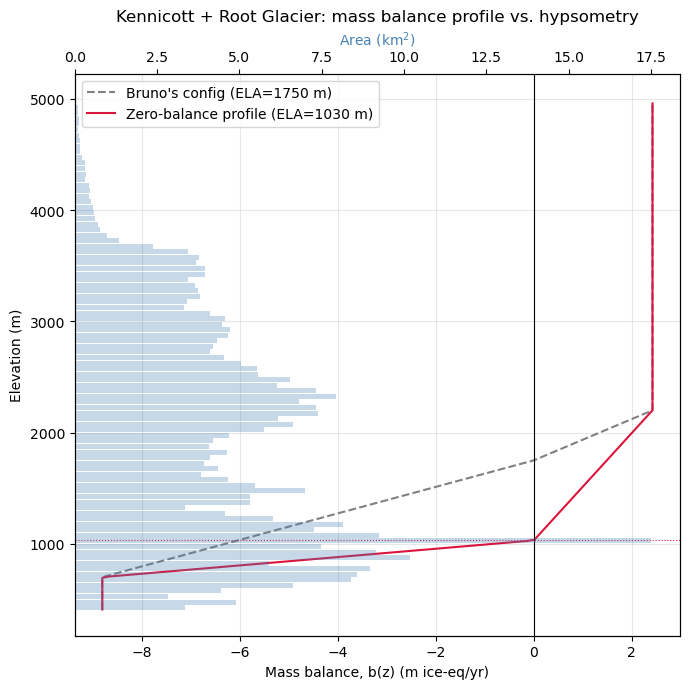

In [12]:
def plot_balance_profile(elevations, pism_params, zero_balance_params, ela_zero_balance,
                          bin_centers, area_km2_per_bin, bin_width):
    fig, ax1 = plt.subplots(figsize=(7, 7))

    z_plot = np.linspace(elevations.min(), elevations.max(), 400)
    ax1.plot(mass_balance_profile(z_plot, **pism_params), z_plot,
             color="gray", ls="--", label=f"Bruno's config (ELA={pism_params['z_ELA']:.0f} m)")
    ax1.plot(mass_balance_profile(z_plot, **zero_balance_params), z_plot,
             color="crimson", label=f"Zero-balance profile (ELA={ela_zero_balance:.0f} m)")
    ax1.axvline(0, color="k", lw=0.8)
    ax1.axhline(ela_zero_balance, color="crimson", lw=0.8, ls=":")
    ax1.set_xlabel("Mass balance, b(z) (m ice-eq/yr)")
    ax1.set_ylabel("Elevation (m)")
    ax1.legend(loc="upper left")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twiny()
    ax2.barh(bin_centers, area_km2_per_bin, height=bin_width * 0.9,
             color="steelblue", alpha=0.3, zorder=0)
    ax2.set_xlabel("Area (km$^2$)", color="steelblue")

    ax1.set_title("Kennicott + Root Glacier: mass balance profile vs. hypsometry")
    plt.tight_layout()
    plt.show()


plot_balance_profile(elevations, PISM_PARAMS, check_params, ela_zero_balance,
                      bin_centers, area_km2_per_bin, BIN_WIDTH)


## 8. Sensitivity: zero-balance ELA across a range of balance gradients

Bruno's config fixes the ablation and accumulation gradients (via
`M_min`/`z_M_min` and `M_max`/`z_M_max`). More generally, *many* combinations
of ELA + gradients can zero out the net balance for this glacier's shape --
a steeper ablation gradient just needs a correspondingly higher ELA (more
accumulation area) to compensate, and vice versa. The plot below sweeps the
ablation gradient (below `z_ELA`) and accumulation gradient (above `z_ELA`)
over a plausible range and solves for the zero-balance ELA at each
combination, holding the PISM elevation caps (`z_M_min`, `z_M_max`) fixed.


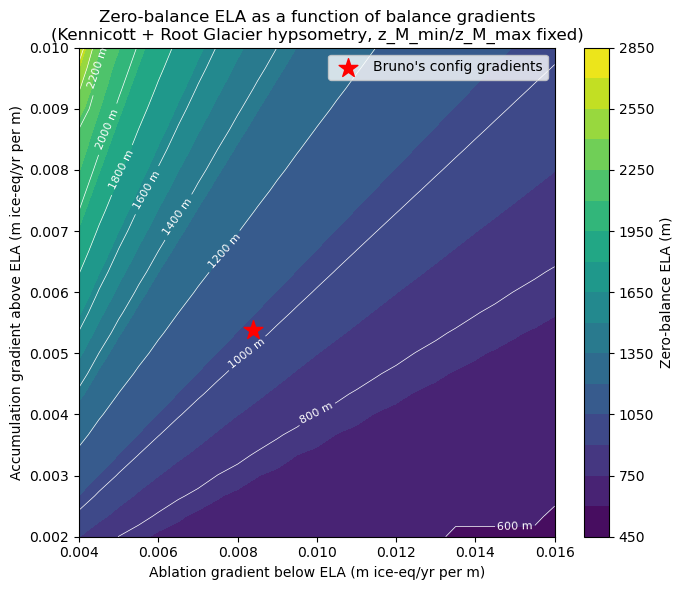

In [13]:
def make_gradient_params(grad_ablation, grad_accumulation, base_params):
    """Rebuild M_min/M_max from balance gradients (m ice-eq/yr per m of elevation),
    holding z_M_min / z_M_max / z_ELA from base_params.
    """
    params = dict(base_params)
    params["M_min"] = -grad_ablation * (base_params["z_ELA"] - base_params["z_M_min"])
    params["M_max"] = grad_accumulation * (base_params["z_M_max"] - base_params["z_ELA"])
    params["M_limit_min"] = params["M_min"]
    params["M_limit_max"] = params["M_max"]
    return params


grad_ablation_range = np.linspace(0.004, 0.016, 25)       # m ice-eq/yr per m, below ELA
grad_accumulation_range = np.linspace(0.002, 0.010, 25)   # m ice-eq/yr per m, above ELA

ela_grid = np.full((len(grad_accumulation_range), len(grad_ablation_range)), np.nan)

for i, g_acc in enumerate(grad_accumulation_range):
    for j, g_abl in enumerate(grad_ablation_range):
        params = make_gradient_params(g_abl, g_acc, PISM_PARAMS)
        try:
            ela_grid[i, j] = brentq(
                net_balance_vs_ela, z_lo, z_hi, args=(params, bin_centers, area_km2_per_bin)
            )
        except ValueError:
            pass  # no root in bracket (all-ablation or all-accumulation gradient combo)


def plot_ela_sensitivity(grad_ablation_range, grad_accumulation_range, ela_grid, pism_params):
    fig, ax = plt.subplots(figsize=(7, 6))
    cf = ax.contourf(grad_ablation_range, grad_accumulation_range, ela_grid, levels=20, cmap="viridis")
    cs = ax.contour(grad_ablation_range, grad_accumulation_range, ela_grid, levels=10, colors="white", linewidths=0.5)
    ax.clabel(cs, fmt="%.0f m", fontsize=8)
    ax.scatter(
        [-pism_params["M_min"] / (pism_params["z_ELA"] - pism_params["z_M_min"])],
        [pism_params["M_max"] / (pism_params["z_M_max"] - pism_params["z_ELA"])],
        color="red", marker="*", s=200, label="Bruno's config gradients", zorder=5,
    )
    fig.colorbar(cf, ax=ax, label="Zero-balance ELA (m)")
    ax.set_xlabel("Ablation gradient below ELA (m ice-eq/yr per m)")
    ax.set_ylabel("Accumulation gradient above ELA (m ice-eq/yr per m)")
    ax.set_title("Zero-balance ELA as a function of balance gradients\n(Kennicott + Root Glacier hypsometry, z_M_min/z_M_max fixed)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


plot_ela_sensitivity(grad_ablation_range, grad_accumulation_range, ela_grid, PISM_PARAMS)


## Summary

- The Kennicott and Root Glacier outlines (`RGI60-01.15645`, `RGI60-01.26722`)
  were merged into a single outline and used to clip the COP30 DEM (already
  in UTM Zone 7N, EPSG:32607) for accurate, equal-area pixel statistics.
- Its hypsometry (area-elevation distribution) was combined with the
  PISM `elevation_dependent` piecewise-linear mass balance parameterization
  Bruno is using for this glacier.
- Holding the ablation/accumulation gradients from that config fixed, the
  **ELA that gives zero net mass balance** was solved for directly, and
  compared against the ELA (1750 m) actually specified in the config.
- More broadly, there is a one-parameter family of (ELA, gradient) pairs
  that all zero out the net balance for this specific glacier shape -- the
  contour plot above maps that family out, so a steeper ablation gradient
  can be offset by a correspondingly higher ELA / less steep accumulation
  gradient, and vice versa.

Natural next steps: replace the piecewise-linear profile with an
observationally-calibrated one (e.g. from geodetic or stake mass-balance
data), or repeat this analysis through time using a DEM time series to see
how the zero-balance profile has shifted as the glacier has thinned.
